# Trade Sentinel: conviction notebook

The live demo shows three hand-written cases. This notebook asks the harder question: **does the engine still work on hundreds of companies it has never seen, including ones designed to fool it?**

What it does:
1. **Generates many random synthetic portfolios.** Fraud is injected at varying difficulty, alongside *hard negatives*: honest businesses that look suspicious.
2. **Measures the production engine as-is** (`scoring.py`, unchanged): precision, recall, which fraud variants it catches, which honest businesses it wrongly flags.
3. **Trains models** on the engine's features, and on the engine's features **plus the investigation's evidence** (was the buyer's money received? does every financed invoice have a real sale?). This shows how much the evidence steps add.
4. **Checks the trained model agrees with the three demo cases**, then saves the model and a one-table summary you can quote.

Everything is synthetic. Change the knobs in **Config** and re-run all cells to train on a different mix.

In [1]:
import sys, json, re, random, time
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from data_gen import Entity, EntityType, Transaction
from scoring import (score_all_entities, find_duplicate_financing, find_trade_cycles,
                     build_sale_adjacency, canonical_ref, RISK_WEIGHTS)
from scenarios import build_demo_dataset

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})
FRAUD_C, CLEAN_C, ACCENT = "#c1543f", "#8fae8b", "#171614"
print("Engine loaded from", ROOT)

Engine loaded from /Users/swaraj/Documents/Zeyro-BPF


## 1. Config

Each portfolio has ~120 companies and ~4,000 transactions. `N_PORTFOLIOS = 30` builds a training set of about 2,500 exporters in under a minute.

| Knob | Meaning |
|---|---|
| `N_LEGIT` | ordinary exporters per portfolio |
| `N_DUP` | exporters that finance one invoice twice |
| `N_RINGS` | circular-trade rings (2–4 members each) |
| `N_STANDING` | **hard negative:** repeat orders to one buyer, same amount, consecutive invoice numbers, alternating financiers |
| `N_RECIPROCAL` | **hard negative:** pairs of honest companies that buy from each other *and* sell to outside buyers |
| `N_BIG` | **hard negative:** very busy honest exporters |
| `DUP_VARIANTS` | how the fraudster disguises the second invoice reference (see §2) |

In [2]:
N_PORTFOLIOS = 30
N_LEGIT, N_DUP, N_RINGS = 50, 8, 3
N_STANDING, N_RECIPROCAL, N_BIG = 4, 2, 4
DUP_VARIANTS = ["exact", "reformatted", "suffix", "transposed"]
AMOUNT_JITTER = [0.0, 0.003, 0.03]      # second submission's amount differs by up to this fraction
GAP_DAYS = [1, 3, 7, 20]                # days between the two submissions
RING_ROUNDS = (1, 4)                    # min/max laps around a ring
SEED0 = 1000

## 2. Synthetic portfolio generator

Every company follows the full trade lifecycle, recorded as four transaction kinds. These are the same kinds the production app uses:
- `sale`: exporter → buyer, the goods invoice
- `financing_request`: exporter → factor or bank
- `funding`: financier → exporter, at 88–96% of face value
- `settlement`: buyer → financier, 30–90 days later (about 4% of honest invoices are never paid, for realism)

**Fraud patterns injected:**

| Pattern | Variant | Second reference looks like |
|---|---|---|
| Duplicate financing | `exact` | `INV-2026-0417` (identical) |
| | `reformatted` | `inv 2026 417` |
| | `suffix` | `INV-2026-0417A`, `INV-2026-0417-R`, `INV-2026-0417/1` |
| | `transposed` | `INV-2026-0471` (digits swapped) |
| Circular trade | 2–4 members, 1–4 laps | half the rings also do some genuine outside trade to blend in |

In a duplicate fraud, the buyer pays **only the first financier**. That's the real-world signature, and the investigation's buyer-payment check exploits it.

In [3]:
DAY = 86400
REF_STYLES = [lambda p, y, n: f"{p}-{y}-{n:04d}", lambda p, y, n: f"{p}/{y}/{n}", lambda p, y, n: f"{p}{y}{n:05d}"]

def disguise(ref, variant, rng):
    if variant == "exact":
        return ref
    if variant == "reformatted":
        prefix = re.match(r"[A-Za-z]*", ref).group(0)
        return f"{prefix.lower()} " + " ".join(str(int(d)) for d in re.findall(r"\d+", ref))
    if variant == "suffix":
        return ref + rng.choice(["A", "-R", "/1"])
    if variant == "transposed":
        s = list(ref)
        idx = [i for i in range(len(s) - 1) if s[i].isdigit() and s[i + 1].isdigit() and s[i] != s[i + 1]]
        i = idx[-1]; s[i], s[i + 1] = s[i + 1], s[i]
        return "".join(s)
    raise ValueError(variant)


class Portfolio:
    def __init__(self, seed):
        self.rng = r = random.Random(seed)
        self.entities, self.txns, self.labels, self.n, self.ex = [], [], {}, 0, 0
        self.buyers = [self._ent(f"B{i:03d}", EntityType.IMPORTER, r.uniform(1e6, 8e6)) for i in range(30)]
        self.factors = [self._ent(f"F{i:02d}", EntityType.FACTOR, r.uniform(1e7, 5e7)) for i in range(10)]
        self.banks = [self._ent(f"K{i:02d}", EntityType.BANK, r.uniform(5e7, 1e8)) for i in range(4)]

    def _ent(self, eid, etype, vol):
        self.entities.append(Entity(eid, etype, eid, vol)); return eid

    def tx(self, s, d, amt, ref, day, kind):
        self.txns.append(Transaction(f"T{self.n}", s, d, round(amt, 2), ref, int(day * DAY), kind=kind)); self.n += 1

    def new_exporter(self, label, typology, tag, **meta):
        eid = f"X{self.ex:04d}"; self.ex += 1
        self.labels[eid] = {"label": label, "typology": typology, "tag": tag, **meta}
        return eid

    def close(self, eid, total):
        self.entities.append(Entity(eid, EntityType.EXPORTER, eid, max(total * self.rng.uniform(0.6, 2.5), 5e4)))

    def history(self, eid, n_inv, span=120):
        r = self.rng
        h = {"prefix": r.choice(["INV", "EXP", "SI", "TX"]), "style": r.choice(REF_STYLES), "number": r.randint(1, 900),
             "buyers": r.sample(self.buyers, r.randint(1, 5)), "fins": r.sample(self.factors + self.banks, r.randint(1, 3)), "total": 0.0}
        for _ in range(n_inv):
            h["number"] += 1
            ref = h["style"](h["prefix"], 2026, h["number"])
            amt, day = r.uniform(2e4, 6e5), r.uniform(0, span)
            buyer, fin = r.choice(h["buyers"]), r.choice(h["fins"])
            self.tx(eid, buyer, amt, ref, day, "sale")
            self.tx(eid, fin, amt, ref, day + r.uniform(0, 3), "financing_request")
            self.tx(fin, eid, amt * r.uniform(0.88, 0.96), ref, day + r.uniform(1, 5), "funding")
            if r.random() > 0.04:
                self.tx(buyer, fin, amt, ref, day + r.uniform(30, 90), "settlement")
            h["total"] += amt
        return h

    # ---- honest companies ----
    def legit(self, tag="legit", n=(3, 25), span=120):
        eid = self.new_exporter(0, "none", tag)
        self.close(eid, self.history(eid, self.rng.randint(*n), span)["total"])

    def standing_order(self):
        r = self.rng
        eid = self.new_exporter(0, "none", "standing_order")
        h = self.history(eid, r.randint(2, 8))
        buyer, fins, amt = r.choice(h["buyers"]), r.sample(self.factors, 2), r.uniform(5e4, 3e5)
        for k in range(r.randint(4, 8)):
            h["number"] += 1
            ref = h["style"](h["prefix"], 2026, h["number"])
            day, fin = 20 + k * 7, fins[k % 2]
            self.tx(eid, buyer, amt, ref, day, "sale")
            self.tx(eid, fin, amt, ref, day + 1, "financing_request")
            self.tx(fin, eid, amt * 0.95, ref, day + 2, "funding")
            self.tx(buyer, fin, amt, ref, day + 40, "settlement")
            h["total"] += amt
        self.close(eid, h["total"])

    def reciprocal_pair(self):
        r = self.rng
        a, b = self.new_exporter(0, "none", "reciprocal"), self.new_exporter(0, "none", "reciprocal")
        ha, hb = self.history(a, r.randint(5, 15)), self.history(b, r.randint(5, 15))
        for k in range(r.randint(1, 3)):
            amt = r.uniform(5e4, 2e5)
            self.tx(a, b, amt, f"RA{a}-{k}", 30 + k * 20, "sale"); self.tx(b, a, amt, f"RA{a}-{k}", 70 + k * 20, "settlement")
            self.tx(b, a, amt * 1.1, f"RB{b}-{k}", 40 + k * 20, "sale"); self.tx(a, b, amt * 1.1, f"RB{b}-{k}", 80 + k * 20, "settlement")
        self.close(a, ha["total"]); self.close(b, hb["total"])

    # ---- fraud ----
    def duplicate(self, variant, jitter, gap):
        r = self.rng
        eid = self.new_exporter(1, "duplicate_financing", "dup", variant=variant, jitter=jitter, gap=gap)
        h = self.history(eid, r.randint(3, 25))
        h["number"] += 1
        ref = h["style"](h["prefix"], 2026, h["number"])
        amt, day, buyer = r.uniform(1e5, 7e5), r.uniform(60, 130), r.choice(h["buyers"])
        f1, f2 = r.sample(self.factors + self.banks, 2)
        ref2, amt2 = disguise(ref, variant, r), amt * (1 + r.uniform(-jitter, jitter))
        self.tx(eid, buyer, amt, ref, day, "sale")
        self.tx(eid, f1, amt, ref, day, "financing_request"); self.tx(f1, eid, amt * 0.95, ref, day + 1, "funding")
        self.tx(eid, f2, amt2, ref2, day + gap, "financing_request"); self.tx(f2, eid, amt2 * 0.95, ref2, day + gap + 1, "funding")
        self.tx(buyer, f1, amt, ref, day + 45, "settlement")   # the buyer pays once
        self.close(eid, h["total"] + amt)

    def ring(self, length, rounds, outside):
        r = self.rng
        members = [self.new_exporter(1, "circular_trade", "ring", ring_len=length, rounds=rounds, outside=outside) for _ in range(length)]
        bank, totals, value = r.choice(self.banks), {m: 0.0 for m in members}, r.uniform(3e5, 1.5e6)
        for rnd in range(rounds):
            for i, s in enumerate(members):
                b, ref, day = members[(i + 1) % length], f"R{s[1:]}-{rnd + 1:03d}", 5 + rnd * 20 + i * 3
                self.tx(s, b, value, ref, day, "sale")
                self.tx(s, bank, value, ref, day + 1, "financing_request"); self.tx(bank, s, value * 0.9, ref, day + 2, "funding")
                self.tx(b, s, value, ref, day + 3, "settlement")
                totals[s] += value; value *= 1 + r.uniform(0, 0.03)
        for m in members:
            if outside:
                totals[m] += self.history(m, r.randint(3, 10))["total"]
            self.close(m, totals[m])


def build_portfolio(seed):
    p = Portfolio(seed); r = p.rng
    for _ in range(N_LEGIT): p.legit()
    for _ in range(N_BIG): p.legit(tag="high_volume", n=(30, 50), span=150)
    for _ in range(N_STANDING): p.standing_order()
    for _ in range(N_RECIPROCAL): p.reciprocal_pair()
    for _ in range(N_DUP): p.duplicate(r.choice(DUP_VARIANTS), r.choice(AMOUNT_JITTER), r.choice(GAP_DAYS))
    for _ in range(N_RINGS): p.ring(r.randint(2, 4), r.randint(*RING_ROUNDS), r.random() < 0.5)
    return p

p = build_portfolio(SEED0)
print(f"One portfolio: {len(p.entities)} companies, {len(p.txns)} transactions")
print(Counter(v['tag'] for v in p.labels.values()))

One portfolio: 123 companies, 3991 transactions
Counter({'legit': 50, 'ring': 9, 'dup': 8, 'high_volume': 4, 'standing_order': 4, 'reciprocal': 4})


## 3. Features

**Engine features.** These are the nine signals the production engine computes today (`scoring.py`, untouched), plus its final risk score.

**Evidence features.** These are computed from the same checks the investigation walks through in the chat, but not yet used in the risk score:

| Feature | Question it answers |
|---|---|
| `ev_dup_exact` | invoices financed twice with the same number (possibly reformatted) |
| `ev_dup_near` | financed twice via the looser "similar reference" rule |
| `ev_unmatched_financing` | share of financing requests with **no matching sale** to any buyer |
| `ev_unrepaid_financing` | share of financing requests the buyer **never repaid** |
| `ev_loop_rounds` | laps around the biggest closed trading loop |
| `ev_loop_outside_share` | share of the loop members' sales that go to buyers **outside** the loop |
| `ev_financed_vs_declared` | financed volume ÷ declared annual volume |

In [4]:
ENGINE_FEATURES = list(RISK_WEIGHTS.keys())
EVIDENCE_FEATURES = ["ev_dup_exact", "ev_dup_near", "ev_unmatched_financing", "ev_unrepaid_financing",
                     "ev_loop_rounds", "ev_loop_outside_share", "ev_financed_vs_declared"]
TYPOLOGY_PATTERNS = {"duplicate_invoice_financing", "circular_trade"}

def evidence_features(eid, ents, txns, by_entity, sale_adj):
    mine = by_entity.get(eid, [])
    reqs = [t for t in mine if t.kind == "financing_request" and t.from_entity == eid]
    sale_keys = {canonical_ref(t.invoice_ref) for t in mine if t.kind == "sale" and t.from_entity == eid}
    repaid = {(t.to_entity, canonical_ref(t.invoice_ref)) for t in txns if t.kind == "settlement"}
    pairs = find_duplicate_financing(eid, txns, ents)
    cycles = find_trade_cycles(eid, sale_adj)
    loop_outside = 1.0
    if cycles:
        ring = set(max(cycles, key=lambda c: c["rounds"])["path"])
        sales = [(m, b) for m in ring for b, lst in sale_adj.get(m, {}).items() for _ in lst]
        loop_outside = sum(1 for _, b in sales if b not in ring) / max(len(sales), 1)
    n = max(len(reqs), 1)
    return {
        "ev_dup_exact": sum(p["canonical_match"] for p in pairs),
        "ev_dup_near": sum(not p["canonical_match"] for p in pairs),
        "ev_unmatched_financing": sum(canonical_ref(t.invoice_ref) not in sale_keys for t in reqs) / n,
        "ev_unrepaid_financing": sum((t.to_entity, canonical_ref(t.invoice_ref)) not in repaid for t in reqs) / n,
        "ev_loop_rounds": max((c["rounds"] for c in cycles), default=0),
        "ev_loop_outside_share": loop_outside,
        "ev_financed_vs_declared": sum(t.amount for t in reqs) / max(ents[eid].declared_volume, 1),
    }

def featurise(entities, txns, labels=None, portfolio=None):
    evidence = score_all_entities(entities, txns)
    ents = {e.entity_id: e for e in entities}
    by_entity = {}
    for t in txns:
        by_entity.setdefault(t.from_entity, []).append(t); by_entity.setdefault(t.to_entity, []).append(t)
    sale_adj = build_sale_adjacency(txns)
    rows = []
    for ev in evidence:
        if ev.entity_type != "exporter":
            continue
        row = {"portfolio": portfolio, "entity_id": ev.entity_id, "risk_score": ev.risk_score,
               "engine_typology_flag": int(bool(TYPOLOGY_PATTERNS & set(ev.matched_patterns))),
               "patterns": ",".join(ev.matched_patterns), **ev.features,
               **evidence_features(ev.entity_id, ents, txns, by_entity, sale_adj)}
        if labels is not None:
            row.update({k: v for k, v in labels[ev.entity_id].items()})
        rows.append(row)
    return pd.DataFrame(rows)

t0 = time.time()
frames = []
for i in range(N_PORTFOLIOS):
    port = build_portfolio(SEED0 + i)
    frames.append(featurise(port.entities, port.txns, port.labels, portfolio=i))
df = pd.concat(frames, ignore_index=True)
print(f"{len(df)} exporters from {N_PORTFOLIOS} portfolios in {time.time() - t0:.1f}s · "
      f"{df.label.sum()} fraudulent ({df.label.mean():.0%})")
df.groupby("tag").agg(companies=("label", "size"), fraud=("label", "sum"), avg_engine_score=("risk_score", "mean")).round(1)

2374 exporters from 30 portfolios in 10.8s · 514 fraudulent (22%)


,companies,fraud,avg_engine_score
tag,,,
dup,240,240,63.0
high_volume,120,0,42.4
legit,1500,0,38.8
reciprocal,120,0,63.2
ring,274,274,60.8
standing_order,120,0,72.5


## 4. The production engine, as-is

Two ways to read the engine:
- **Typology flag:** the engine detected *duplicate financing* or *circular trade*. This is what puts a case in the "needs review" queue.
- **Risk score:** the 0–100 blend. The app treats > 70 as escalate and ≥ 50 as an alert.

In [5]:
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_score, recall_score,
                             roc_curve, precision_recall_curve, confusion_matrix)

def summary(y, flag, score=None, name=""):
    out = {"model": name, "precision": precision_score(y, flag, zero_division=0), "recall": recall_score(y, flag),
           "false_positives": int(((flag == 1) & (y == 0)).sum()), "missed_frauds": int(((flag == 0) & (y == 1)).sum())}
    if score is not None:
        out.update({"ROC_AUC": roc_auc_score(y, score), "PR_AUC": average_precision_score(y, score)})
    return out

y = df.label.values
rows = [summary(y, df.engine_typology_flag.values, df.risk_score.values, "Engine: typology flag"),
        summary(y, (df.risk_score >= 50).astype(int).values, df.risk_score.values, "Engine: score ≥ 50"),
        summary(y, (df.risk_score > 70).astype(int).values, df.risk_score.values, "Engine: score > 70")]
baseline = pd.DataFrame(rows).set_index("model").round(3)
baseline

,precision,recall,false_positives,missed_frauds,ROC_AUC,PR_AUC
model,,,,,,
Engine: typology flag,0.603,0.864,292,70,0.842,0.55
Engine: score ≥ 50,0.601,0.856,292,74,0.842,0.55
Engine: score > 70,0.528,0.344,158,337,0.842,0.55


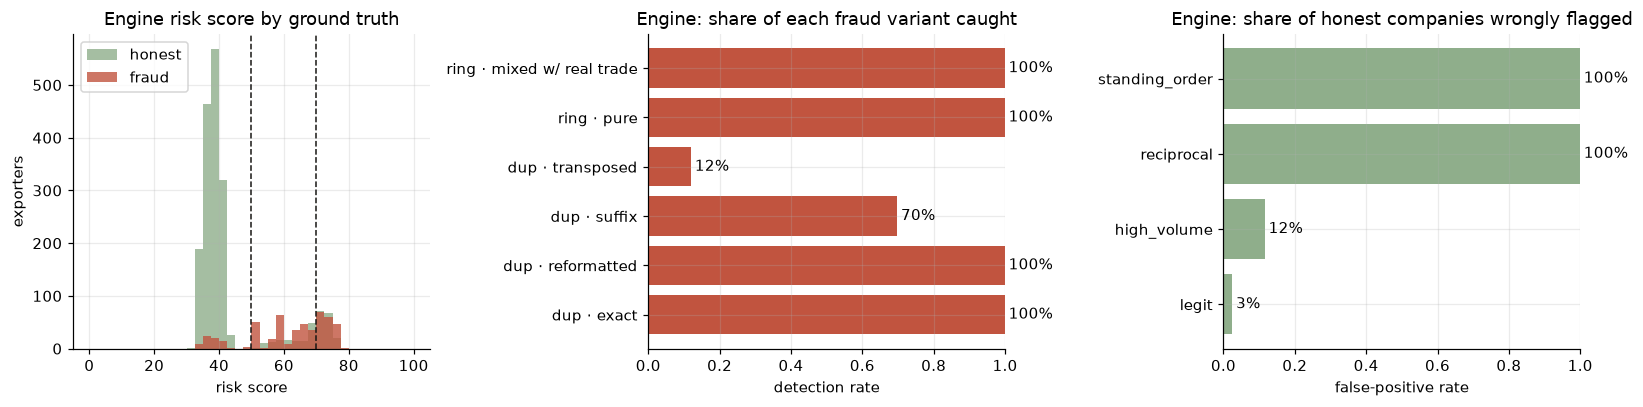

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
bins = np.linspace(0, 100, 41)
axes[0].hist(df[df.label == 0].risk_score, bins, color=CLEAN_C, alpha=.8, label="honest")
axes[0].hist(df[df.label == 1].risk_score, bins, color=FRAUD_C, alpha=.8, label="fraud")
for x in (50, 70): axes[0].axvline(x, color=ACCENT, ls="--", lw=1)
axes[0].set(title="Engine risk score by ground truth", xlabel="risk score", ylabel="exporters"); axes[0].legend()

fraud = df[df.label == 1]
by_var = pd.concat([
    fraud[fraud.tag == "dup"].groupby("variant").engine_typology_flag.mean().rename(lambda v: f"dup · {v}"),
    fraud[fraud.tag == "ring"].groupby("outside").engine_typology_flag.mean().rename(lambda o: f"ring · {'mixed w/ real trade' if o else 'pure'}"),
])
axes[1].barh(by_var.index, by_var.values, color=FRAUD_C)
axes[1].set(xlim=(0, 1), title="Engine: share of each fraud variant caught", xlabel="detection rate")
for i, v in enumerate(by_var.values): axes[1].text(v + .01, i, f"{v:.0%}", va="center")

honest = df[df.label == 0]
fp = honest.groupby("tag").engine_typology_flag.mean().sort_values()
axes[2].barh(fp.index, fp.values, color=CLEAN_C)
axes[2].set(xlim=(0, 1), title="Engine: share of honest companies wrongly flagged", xlabel="false-positive rate")
for i, v in enumerate(fp.values): axes[2].text(v + .01, i, f"{v:.0%}", va="center")
plt.tight_layout(); plt.show()

**How to read this.** Compare the middle chart (what the engine catches) with the right chart (who it wrongly accuses).
- Weak spots on the fraud side are usually `transposed` and some `suffix` references. They share no invoice number with the original, so the matcher can't link them.
- Weak spots on the honest side are `standing_order` (same buyer, same amount, consecutive numbers look like a disguised duplicate) and `reciprocal` pairs (two companies that trade both ways form a two-member "loop").

These are exactly the cases where the investigation's **buyer-payment** and **outside-sales** checks should help. The next section tests that.

## 5. Train

Three models, all evaluated with **cross-validation grouped by portfolio**. The model is always scored on portfolios it never saw during training, so it can't memorise a portfolio's quirks.

| Model | Inputs | Purpose |
|---|---|---|
| Logistic regression | 9 engine features | learn weights for today's signals and compare with the hand-set ones |
| Gradient boosting | 9 engine features | best achievable with today's signals |
| Gradient boosting | engine + 7 evidence features | how much the investigation evidence adds |

In [7]:
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import HistGradientBoostingClassifier

def cv_predict(make_model, X, y, groups, folds=5):
    oof = np.zeros(len(y))
    for tr, te in GroupKFold(n_splits=folds).split(X, y, groups):
        m = make_model().fit(X[tr], y[tr])
        oof[te] = m.predict_proba(X[te])[:, 1]
    return oof

X_engine = df[ENGINE_FEATURES].values
X_full = df[ENGINE_FEATURES + EVIDENCE_FEATURES].values
groups = df.portfolio.values

make_lr = lambda: make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight="balanced"))
make_gb = lambda: HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, max_leaf_nodes=15, random_state=0)

df["p_lr_engine"] = cv_predict(make_lr, X_engine, y, groups)
df["p_gb_engine"] = cv_predict(make_gb, X_engine, y, groups)
df["p_gb_full"] = cv_predict(make_gb, X_full, y, groups)

def best_threshold(y, p, min_precision=0.9):
    prec, rec, thr = precision_recall_curve(y, p)
    ok = np.where(prec[:-1] >= min_precision)[0]
    return float(thr[ok[np.argmax(rec[ok])]]) if len(ok) else 0.5

results = baseline.reset_index().to_dict("records")
thresholds = {}
for col, name in [("p_lr_engine", "Logistic reg · engine features"), ("p_gb_engine", "Boosting · engine features"),
                  ("p_gb_full", "Boosting · engine + evidence")]:
    thresholds[col] = t = best_threshold(y, df[col].values)
    df[col + "_flag"] = (df[col] >= t).astype(int)
    results.append(summary(y, df[col + "_flag"].values, df[col].values, name))
comparison = pd.DataFrame(results).set_index("model").round(3)
comparison

,precision,recall,false_positives,missed_frauds,ROC_AUC,PR_AUC
model,,,,,,
Engine: typology flag,0.603,0.864,292,70,0.842,0.550
Engine: score ≥ 50,0.601,0.856,292,74,0.842,0.550
Engine: score > 70,0.528,0.344,158,337,0.842,0.550
Logistic reg · engine features,0.900,0.455,26,280,0.946,0.814
Boosting · engine features,0.901,0.652,37,179,0.959,0.892
Boosting · engine + evidence,0.900,0.998,57,1,0.998,0.997


Trained models use the threshold that gives the **highest recall while keeping precision ≥ 90%**. When a fraud analyst opens a case, it should usually be real.

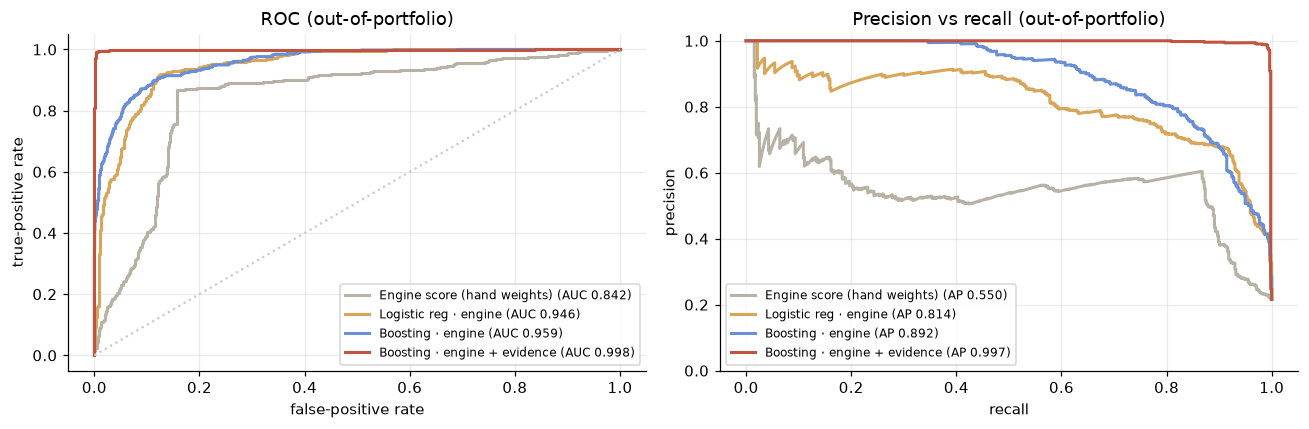

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
curves = [("risk_score", "Engine score (hand weights)", "#b7b2a4"), ("p_lr_engine", "Logistic reg · engine", "#d8a559"),
          ("p_gb_engine", "Boosting · engine", "#6b8fd6"), ("p_gb_full", "Boosting · engine + evidence", FRAUD_C)]
for col, name, c in curves:
    fpr, tpr, _ = roc_curve(y, df[col]); axes[0].plot(fpr, tpr, color=c, lw=2, label=f"{name} (AUC {roc_auc_score(y, df[col]):.3f})")
    prec, rec, _ = precision_recall_curve(y, df[col]); axes[1].plot(rec, prec, color=c, lw=2, label=f"{name} (AP {average_precision_score(y, df[col]):.3f})")
axes[0].plot([0, 1], [0, 1], color="#ccc", ls=":"); axes[0].set(title="ROC (out-of-portfolio)", xlabel="false-positive rate", ylabel="true-positive rate")
axes[1].set(title="Precision vs recall (out-of-portfolio)", xlabel="recall", ylabel="precision", ylim=(0, 1.02))
axes[0].legend(fontsize=8, loc="lower right"); axes[1].legend(fontsize=8, loc="lower left")
plt.tight_layout(); plt.show()

## 6. Where the evidence features change the outcome

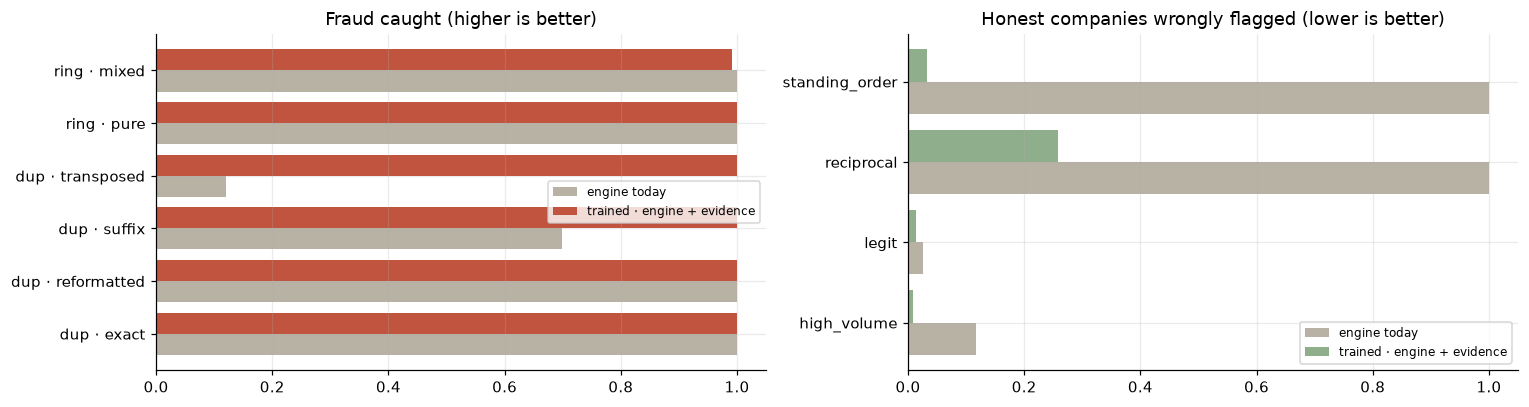

,engine today,trained (engine + evidence)
dup · exact,1.00,1.00
dup · reformatted,1.00,1.00
dup · suffix,0.70,1.00
dup · transposed,0.12,1.00
ring · pure,1.00,1.00
ring · mixed,1.00,0.99
high_volume,0.12,0.01
legit,0.03,0.01
reciprocal,1.00,0.26
standing_order,1.00,0.03


In [9]:
def rates(frame, flag_col):
    fr, ho = frame[frame.label == 1], frame[frame.label == 0]
    caught = pd.concat([fr[fr.tag == "dup"].groupby("variant")[flag_col].mean().rename(lambda v: f"dup · {v}"),
                        fr[fr.tag == "ring"].groupby("outside")[flag_col].mean().rename(lambda o: f"ring · {'mixed' if o else 'pure'}")])
    wrong = ho.groupby("tag")[flag_col].mean()
    return caught, wrong

c0, w0 = rates(df, "engine_typology_flag")
c1, w1 = rates(df, "p_gb_full_flag")
fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
ix = np.arange(len(c0))
axes[0].barh(ix - .2, c0.values, .4, color="#b7b2a4", label="engine today")
axes[0].barh(ix + .2, c1.reindex(c0.index).values, .4, color=FRAUD_C, label="trained · engine + evidence")
axes[0].set(yticks=ix, yticklabels=c0.index, xlim=(0, 1.05), title="Fraud caught (higher is better)"); axes[0].legend(fontsize=8)
ix = np.arange(len(w0))
axes[1].barh(ix - .2, w0.values, .4, color="#b7b2a4", label="engine today")
axes[1].barh(ix + .2, w1.reindex(w0.index).values, .4, color=CLEAN_C, label="trained · engine + evidence")
axes[1].set(yticks=ix, yticklabels=w0.index, xlim=(0, 1.05), title="Honest companies wrongly flagged (lower is better)"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
pd.DataFrame({"engine today": pd.concat([c0, w0]), "trained (engine + evidence)": pd.concat([c1, w1])}).round(2)

## 7. What the models learned

**Left:** logistic-regression weights on the engine's own signals next to the hand-set weights in `scoring.py` (both scaled to sum to 1). If they agree, the hand weights are defensible. If they don't, this shows which signals are over- or under-trusted.

**Right:** which inputs the best model relies on (permutation importance: how much PR-AUC drops when that input is shuffled).

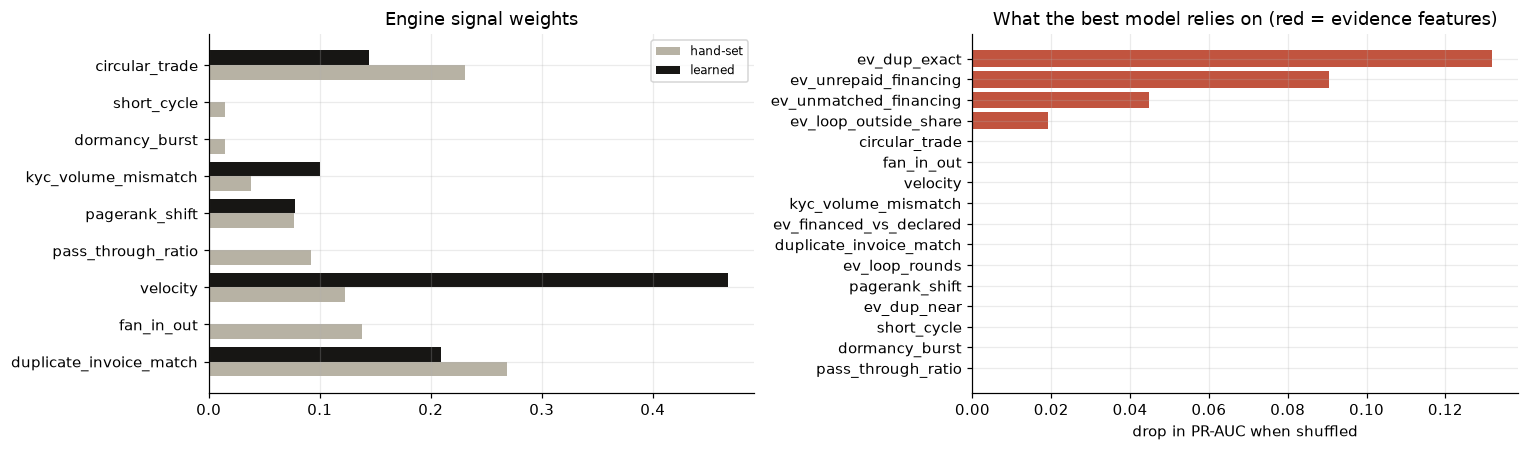

,hand-set (scoring.py),learned (positive part),raw coefficient
duplicate_invoice_match,0.269,0.209,0.649
fan_in_out,0.138,0.000,-2.178
velocity,0.123,0.468,1.451
pass_through_ratio,0.092,0.000,0.000
pagerank_shift,0.077,0.078,0.242
kyc_volume_mismatch,0.038,0.100,0.310
dormancy_burst,0.015,0.000,-0.148
short_cycle,0.015,0.000,0.000
circular_trade,0.231,0.144,0.446


In [10]:
from sklearn.inspection import permutation_importance

lr = make_lr().fit(X_engine, y)
coef = pd.Series(lr[-1].coef_[0], index=ENGINE_FEATURES)
learned = coef.clip(lower=0); learned = learned / learned.sum() if learned.sum() else learned
hand = pd.Series(RISK_WEIGHTS); hand = hand / hand.sum()
weights = pd.DataFrame({"hand-set (scoring.py)": hand, "learned (positive part)": learned, "raw coefficient": coef}).round(3)

gb_full = make_gb().fit(X_full, y)
imp = permutation_importance(gb_full, X_full, y, scoring="average_precision", n_repeats=5, random_state=0)
importance = pd.Series(imp.importances_mean, index=ENGINE_FEATURES + EVIDENCE_FEATURES).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
ix = np.arange(len(hand))
axes[0].barh(ix - .2, weights.iloc[:, 0], .4, color="#b7b2a4", label="hand-set")
axes[0].barh(ix + .2, weights.iloc[:, 1], .4, color=ACCENT, label="learned")
axes[0].set(yticks=ix, yticklabels=hand.index, title="Engine signal weights"); axes[0].legend(fontsize=8)
axes[1].barh(importance.index, importance.values, color=[FRAUD_C if n.startswith("ev_") else "#b7b2a4" for n in importance.index])
axes[1].set(title="What the best model relies on (red = evidence features)", xlabel="drop in PR-AUC when shuffled")
plt.tight_layout(); plt.show()
weights

## 8. Sanity check: the three demo cases

The trained model has **never seen** the hand-written demo scenarios. If it agrees with the live demo, the demo isn't cherry-picked.

In [11]:
demo_entities, demo_txns = build_demo_dataset(seed=107)
demo = featurise(demo_entities, demo_txns)
demo["p_trained"] = gb_full.predict_proba(demo[ENGINE_FEATURES + EVIDENCE_FEATURES].values)[:, 1]
demo["trained_flag"] = demo.p_trained >= thresholds["p_gb_full"]
names = {e.entity_id: e.business_name for e in demo_entities}
demo["company"] = demo.entity_id.map(names)
cases = demo[demo.entity_id.isin(["EXP_TAPTI", "EXP_OPALINE", "EXP_STARFIELD", "EXP_VERIDIAN", "EXP_NORTHSTAR"])]
background = demo[demo.entity_id.str.match(r"EXP_\d")]
display(cases[["company", "risk_score", "patterns", "p_trained", "trained_flag"]].round(3).set_index("company"))
print(f"Background exporters in the demo app flagged by the trained model: {int(background.trained_flag.sum())} of {len(background)}")
print(f"  ...and their share of financing with no sale record behind it: {background.ev_unmatched_financing.mean():.0%}")

,risk_score,patterns,p_trained,trained_flag
company,,,,
Tapti Loom Exports,71.356,duplicate_invoice_financing,1.0,True
Opaline Gems,66.200,"dormant_then_active,circular_trade,kyc_mismatch",1.0,True
Starfield Diamonds,66.200,"dormant_then_active,circular_trade,kyc_mismatch",1.0,True
Veridian Jewels,66.200,"dormant_then_active,circular_trade,kyc_mismatch",1.0,True
Northstar Agro Exports,39.572,"fan_in_out_concentration,dormant_then_active",0.0,False


Background exporters in the demo app flagged by the trained model: 40 of 40
  ...and their share of financing with no sale record behind it: 100%


**Read the background line carefully.** The demo app's ~40 random background exporters come from `data_gen.py`, which only records financing, never the underlying sale or the buyer's payment. The trained model has learned that "financed, but no sale and no repayment" is the signature of fraud, so it flags all of them. That's not a new finding about those companies. It shows two things:
1. The demo's background data is thinner than real trade data. The rule engine doesn't need sale records to score those companies, but the evidence model does.
2. **A trained model is only as good as its inputs**, so it must be fed the full trade lifecycle (sales, financing, payments), as it is here. That's a data requirement for any real deployment: ask partners for invoice, financing *and* settlement feeds.

The model does agree with all five scripted demo companies: Tapti, the three ring members, and Northstar cleared. Those carry full trade records.

## 9. Conviction summary & saved artifacts

In [12]:
import joblib

def row(model):
    r = comparison.loc[model]
    return {"precision": round(float(r.precision), 3), "recall": round(float(r.recall), 3),
            "false_positives": int(r.false_positives), "missed_frauds": int(r.missed_frauds),
            "PR_AUC": round(float(r.PR_AUC), 3), "ROC_AUC": round(float(r.ROC_AUC), 3)}

summary_out = {
    "data": {"portfolios": N_PORTFOLIOS, "exporters": int(len(df)), "fraudulent": int(y.sum()),
             "hard_negatives": int(df.tag.isin(["standing_order", "reciprocal", "high_volume"]).sum()), "synthetic": True},
    "engine_today": row("Engine: typology flag"),
    "trained_engine_plus_evidence": {**row("Boosting · engine + evidence"), "threshold": round(thresholds["p_gb_full"], 4)},
    "detection_by_variant": {"engine_today": c0.round(3).to_dict(), "trained": c1.round(3).to_dict()},
    "false_positive_rate_by_type": {"engine_today": w0.round(3).to_dict(), "trained": w1.round(3).to_dict()},
    "learned_engine_weights": learned.round(4).to_dict(),
    "demo_cases_flagged_by_trained_model": cases.set_index("company").trained_flag.astype(bool).to_dict(),
}
out_dir = ROOT / "models"; out_dir.mkdir(exist_ok=True)
joblib.dump({"model": gb_full, "features": ENGINE_FEATURES + EVIDENCE_FEATURES, "threshold": thresholds["p_gb_full"]},
            out_dir / "trade_sentinel_gb.joblib")
(out_dir / "conviction_metrics.json").write_text(json.dumps(summary_out, indent=2, default=str))

e, t = summary_out["engine_today"], summary_out["trained_engine_plus_evidence"]
print(f"Tested on {summary_out['data']['exporters']:,} synthetic exporters across {N_PORTFOLIOS} unseen portfolios "
      f"({summary_out['data']['fraudulent']} frauds, {summary_out['data']['hard_negatives']} deliberately tricky honest companies).\n")
print(f"  Engine today      precision {e['precision']:.0%}  recall {e['recall']:.0%}  "
      f"false alarms {e['false_positives']}  missed {e['missed_frauds']}")
print(f"  Trained + evidence precision {t['precision']:.0%}  recall {t['recall']:.0%}  "
      f"false alarms {t['false_positives']}  missed {t['missed_frauds']}")
print(f"\nSaved {out_dir / 'trade_sentinel_gb.joblib'} and {out_dir / 'conviction_metrics.json'}")

Tested on 2,374 synthetic exporters across 30 unseen portfolios (514 frauds, 360 deliberately tricky honest companies).

  Engine today      precision 60%  recall 86%  false alarms 292  missed 70
  Trained + evidence precision 90%  recall 100%  false alarms 57  missed 1

Saved /Users/swaraj/Documents/Zeyro-BPF/models/trade_sentinel_gb.joblib and /Users/swaraj/Documents/Zeyro-BPF/models/conviction_metrics.json


## 10. Honest limits

- **The trained model's near-perfect score is optimistic.** Its strongest inputs (buyer never repaid, financing with no matching sale) mirror how this generator creates fraud: the fraudster finances an extra invoice and the buyer pays once. The *direction* is the real result: evidence from the investigation steps removes most false alarms, especially standing orders and honest two-way trade. The exact percentage is not.
- **The engine's precision here is harsher than in real life.** This test deliberately plants 360 tricky honest companies (15% of the data). Standing orders and two-way traders are all flagged by today's rules. A normal portfolio has far fewer look-alikes.
- **Some learned weights reflect the generator, not the world.** For example, velocity gets a large weight because ring members transact unusually often in this simulation. Treat the learned weights as a check on the hand-set ones, not as a replacement.
- **Synthetic data.** The generator encodes our own beliefs about how fraud looks. High scores here prove the logic is consistent and robust to the variants we thought of, not that it works on a real portfolio. Real labelled cases (e.g. from a factoring partner's historical write-offs) are the next step.
- **The buyer-payment signal needs time.** `ev_unrepaid_financing` only works once the buyer's payment is due (30–90 days). Early in an invoice's life, the reference and graph checks carry the decision.
- **Two engine blind spots this notebook exposes:**
  - references with no shared invoice number (transposed digits, extra numeric suffixes)
  - two-company "loops" that are really honest two-way trade

  The evidence features fix most of both. They're the natural next change to `scoring.py`, after the demo, once the build is unfrozen.
- **Not wired into the live app.** The saved model is an artifact for evaluation. The demo runs the rule engine, whose every flag the agent can explain step by step.